In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable

from os.path import join
import os
from functools import partial
import pathlib
from pathlib import Path
import shutil

from joblib import Parallel, delayed
import joblib

import gc
import subprocess
import glob
from credit.pbs import get_num_cpus

In [2]:
# load zarr
path_2025 = "/glade/derecho/scratch/dkimpara/goes-cloud-dataset/goes_10km_2025.zarr"
path_zarr = "/glade/derecho/scratch/dkimpara/goes-cloud-dataset/goes_10km.zarr"

def open_zarr(dataset_path):
    zarr_ds = xr.open_dataset(dataset_path, consolidated=False).drop_duplicates(
        dim="t"
    ).sortby(
        "t"
    ).transpose(
        "t", "channel", "latitude", "longitude")

    return zarr_ds


obs_2025 = open_zarr(path_2025)
obs = open_zarr(path_zarr)

In [3]:
# init_time converter util
def convert_init_time(init_time):
    ts = pd.Timestamp(init_time)
    new_ts = ts - pd.Timedelta(5, "m")
    return new_ts.strftime("%Y-%m-%dT%H:%M:")

def glob_for_folder(path, new_init_time):
    globpath = join(path, f"{new_init_time}*")
    matches = glob.glob(globpath)
    try:
        path = matches[0]
    except:
        print(path)
    return path

# 2022 intra model comp

In [4]:
channel = 13
forecast_hours = [1, 2, 3, 5]

init_time = "2022-12-16T12:00:00" # whole hour times, model size comp
# init_time = "2022-12-16T18:00:00" # whole hour times, timestep comp

# init_time = "2025-06-18T18:00:00"
# init_time = "2025-06-28T06:00:00"
# init_time = "2025-07-05T00:00:00"
# init_time = "2025-07-06T00:00:00"
# init_time = "2025-07-07T06:00:00"

#### full domain
lat_bounds = []
lon_bounds = []
xticks = list(range(-120,-29,30))
yticks = list(range(-50,51,25))

#### Americas/Nhem
# lat_bounds = [0, 51]
# lon_bounds = [-121,-75]
# xticks = list(range(-120,-74,15))
# yticks = list(range(0,51,25))

model_comparisons = [
    "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_2025",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/DOP/10m_big_dop/forecasts_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/30m_omid/forecasts_2025",
]

model_comparisons = [
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/DOP/10m_big_dop/forecasts_2025",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2022",
    # "/glade/derecho/scratch/dkimpara/goes_10km_train/30m_omid/forecasts_2022",
]
titles = {
    "10m_big": "10 minute DOP+",
    "10m_big_dop": "DOP",
    "20m_big": "20 minute DOP+",
    "20m_big3": "20 minute DOP+",
    "30m_omid": "30 minute DOP+",
    "30m_mpas": "MPAS",
         }

# model size ablation
model_comparisons = [
    "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2022",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts_2022",
    "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_inv/forecasts_2022",
]

titles = {
    "20m_big": "Standard",
    "20m_big3": "Big",
    "20m_inv": "Inverted",
         }

baselines = {
    # "10m_big_2022":  "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_workshop",
    # "30m_mpas":  "/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed",
}



# 2025 mpas comp

In [5]:
# channel = 13
# forecast_hours = [1, 2, 3, 5]
# init_time = "2025-06-28T06:00:00" # whole hour

# lat_bounds = []
# lon_bounds = []
# xticks = list(range(-120,-29,30))
# yticks = list(range(-50,51,25))


# # lat_bounds = [0, 51]
# # lon_bounds = [-121,-75]
# # xticks = list(range(-120,-74,15))
# # yticks = list(range(0,51,25))

# model_comparisons = [
#     "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_2025_eval",
#     # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts",
#     # "/glade/derecho/scratch/dkimpara/goes_10km_train/30m_omid/forecasts",
#     # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts",
#     # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_inv/forecasts",
# ]

# baselines = {
#     # "10m_big_2022":  "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_workshop",
#     "30m_mpas":  "/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed",
# }

# titles = {"30m_mpas": "MPAS",
#           "10m_big": "DOP+",
#          }

# code

In [6]:
model_comparisons = {
    Path(d).parent.name: d for d in model_comparisons
}
comparisons = model_comparisons | baselines

# set zarr
if pd.Timestamp(init_time).year == 2025:
    obs = obs_2025

/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2022/2022-12-16T11:55:06/2022-12-16T12:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2022/2022-12-16T11:55:06/2022-12-16T13:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2022/2022-12-16T11:55:06/2022-12-16T14:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts_2022/2022-12-16T11:55:06/2022-12-16T16:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts_2022/2022-12-16T11:55:06/2022-12-16T12:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts_2022/2022-12-16T11:55:06/2022-12-16T13:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts_2022/2022-12-16T11:55:06/2022-12-16T14:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts_2022/2022-12-16T11:55:06/2022-12-16T16:55:06.nc
/glade/derecho/scratch/dkimpara/goes_10km_train/20m_inv/forecasts_2022/2022-12-16T11

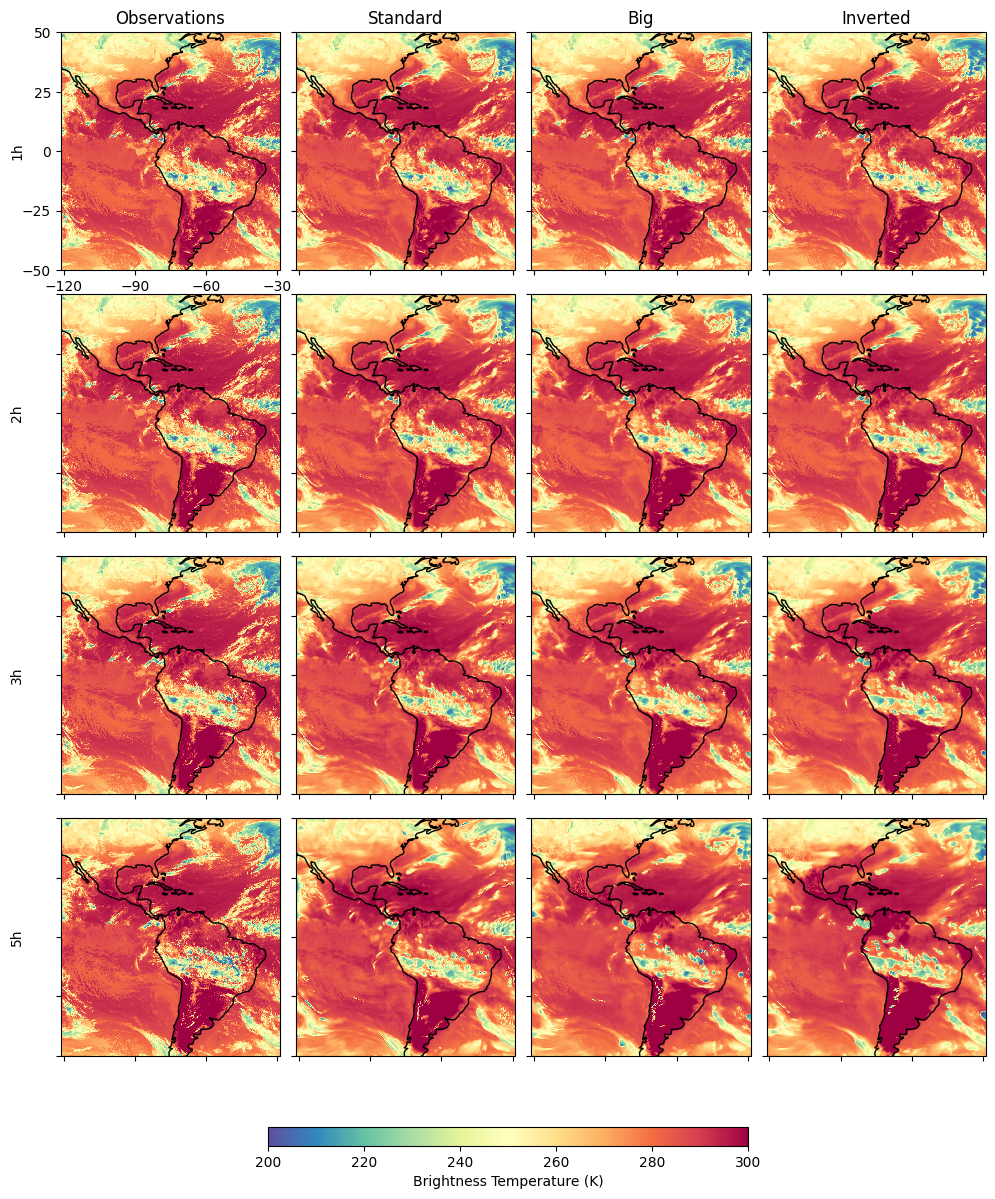

In [7]:
n_rows = len(forecast_hours)
n_cols = len(comparisons) + 1 #obs on left

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3.2 * n_rows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"wspace": 0.05, "hspace": 0.1},

)

# ensure axes is always 2D
if n_rows == 1:
    axes = axes.reshape(1, -1)
if n_cols == 1:
    axes = axes.reshape(-1, 1)

# --- column 0: observations ---
for row, fh in enumerate(forecast_hours):
    ax = axes[row, 0]
    valid_time = pd.Timestamp(init_time) + pd.Timedelta(hours=fh)
    da_obs = obs.sel(t=valid_time, method="nearest").BT_or_R.sel(channel=channel)
    if lat_bounds:
        da_obs = da_obs.sel(latitude=slice(*lat_bounds))
    if lon_bounds:
        da_obs = da_obs.sel(longitude=slice(*lon_bounds))

    im = da_obs.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="Spectral_r",
        vmax=300,
        vmin=200,
        add_colorbar=False,
    )
    ax.coastlines()

    if row == 0:
        ax.set_title("Observations")
    else:
        ax.set_title("")
        
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    if row != 0: ax.set_yticklabels([])
    
    if row != 0:
        ax.set_xticklabels([])

    ax.text(
        -0.2, 0.5, f"{fh}h",
        transform=ax.transAxes,
        rotation=90, va="center", ha="center",
    )
    ax.set_ylabel("")
    ax.set_xlabel("")


for col, (model_name, path) in enumerate(comparisons.items(), start=1):
    # parse timestep (minutes) from key, e.g. "30m_mpas" -> 30
    timestep_min = int(model_name[:2])
    # --- load the data for this model/forecast hour ---
    if "MPAS" not in model_name and "mpas" not in model_name:
        alt_init_time = convert_init_time(init_time)
        path = glob_for_folder(path, alt_init_time)
    else:
        path = join(path, init_time)

    # print(path)
    files = sorted(list(Path(path).iterdir()))

    for row, fh in enumerate(forecast_hours):
        ax = axes[row, col]

        # compute which index/lead time corresponds to this forecast hour
        lead_idx = int((fh * 60) / timestep_min) - 1

        # print(lead_idx)
        # print(files)
        print(files[lead_idx])
        ds = xr.open_dataset(files[lead_idx])
        da = ds.BT_or_R.sel(channel=channel)
        if lat_bounds:
            da = da.sel(latitude=slice(*lat_bounds))
        if lon_bounds:
            da = da.sel(longitude=slice(*lon_bounds))
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="Spectral_r",
            vmax=300,
            vmin=200,
            add_colorbar=False,
        )
        ax.coastlines()

        if row == 0:
            ax.set_title(titles[model_name])
        else:
            ax.set_title("")
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_yticklabels([])
        ax.set_xticklabels([])

        ax.set_xlabel("")
        ax.set_ylabel("")

for ax in axes.ravel():
    ax.set_aspect("equal")  # let axes shrink/grow to fill allotted space

plt.subplots_adjust(wspace=0.01, hspace=0.1, bottom=0.08)

cbar_ax = fig.add_axes([0.3, 0.01, 0.4, 0.015])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation="horizontal", label="Brightness Temperature (K)")


In [8]:

plt.savefig(f"/glade/u/home/dkimpara/GOES_det_npj/figures/forecast_grid_{init_time}.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>